In [1]:
import numpy as np 
from scipy.special import gamma
import math
import matplotlib.pyplot as plt
from cachetools import cached
from rich.table import Table
from rich.console import Console
from rich.progress import track
import warnings
from scipy.optimize import minimize
from tabulate import tabulate
from typing import List, Tuple, Callable, Iterable, Dict
from tqdm import tqdm

In [2]:
datasets = []
for n in (10, 25, 100, 200):
    datasets.append([
    np.random.gamma(
        shape = 3,scale =  2,size = n )
    for _ in range(1000)
    ])

In [3]:
def method_of_moments(data: List[float]) -> Tuple[float, float]:
    t = np.mean(data)
    s = np.std(data)
    shape = (t**2) / (s**2)
    scale = (s**2) / t
    return (shape, scale)

def log_likelihood(shape, scale, data):
    ans = 0
    for d in data:
        val = (shape - 1) * np.log(d)
        val += -d / scale
        val -= np.log(gamma(shape))
        val -= shape * np.log(scale)
        ans += val
    return ans
def mle(data: List[float]) -> Tuple[float,  float]:
    minimize_func = lambda params: -log_likelihood(params[0], params[1], data)
    with warnings.catch_warnings():
        warnings.filterwarnings('ignore', category=RuntimeWarning)
        res = minimize(
            minimize_func,
            x0=[0.12, -0.12],
                bounds= [[None, None], [0.001, None]])
        return res.x

print("mom", method_of_moments(datasets[0][0]))
print("mle", mle(datasets[0][0]))

mom (np.float64(3.3096127416979173), np.float64(1.804944554963955))
mle [2.56910965 2.32519088]


In [4]:
calc_metrics_cache = {}
def calc_metrics(datasets: List[List[float]], estimator: Callable[[List[float]], Tuple[float, float]]) -> Tuple[float, float, float]:
    cache_key = f"{estimator.__name__}-{len(datasets[0])}"
    if val := calc_metrics_cache.get(cache_key):
        return val

    n = len(datasets)
    real_scale = 2
    bias = 0
    variance = 0
    for d in datasets:
        _, scale = estimator(d)
        bias += scale - real_scale
        variance += (scale - real_scale) ** 2
    bias /= n
    variance /= (n - 1)
    mse = bias**2 + variance
    calc_metrics_cache[cache_key] = (bias, variance, mse)
    return bias, variance, mse


In [5]:
tables: Dict[str, Table] = {}
for metric in ("Bias", "Variance", "MSE"):
    table = Table(title=metric, show_header=True, header_style="bold magenta")
    table.add_column("method")
    for n in (10, 25, 100, 200):
        table.add_column(str(n))
    tables[metric ] = table

for f in (method_of_moments, mle):
    row1 = [f.__name__]
    row2 = [f.__name__]
    row3 = [f.__name__]
    for d in tqdm(datasets, desc=f"calculating metrics for {f.__name__}"):
        bias, variance, mse = calc_metrics(d, f)
        row1.append(str(bias))
        row2.append(str(variance))
        row3.append(str(mse))
    print(row1)
    print(row2)
    print(row3)
    tables["Bias"].add_row(*row1)
    tables["Variance"].add_row(*row2)
    tables["MSE"].add_row(*row3)
    
    
console = Console()
for table in tables.values():
    console.print(table)

calculating metrics for method_of_moments: 100%|██████████| 4/4 [00:00<00:00, 149.43it/s]


['method_of_moments', '-0.27497845212867683', '-0.08300912742116774', '-0.013260012907652633', '-0.0013904304967728186']
['method_of_moments', '0.8870559024759873', '0.46533049842061086', '0.11985336706136543', '0.05501052960611661']
['method_of_moments', '0.9626690516110703', '0.4722210136558345', '0.12002919500367654', '0.05501246290308297']


calculating metrics for mle: 100%|██████████| 4/4 [00:43<00:00, 10.80s/it]

['mle', '-0.21756525557891201', '-0.06965475604433169', '-0.015988238755631688', '-0.006215849526998861']
['mle', '0.7758531594066262', '0.3472392586242846', '0.08642259271150479', '0.03828107514629852']
['mle', '0.8231877998417435', '0.35209104366388', '0.08667821649001188', '0.03831971193164081']


                                                       Bias                                                        
┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┓
┃ method            ┃ 10                   ┃ 25                   ┃ 100                   ┃ 200                   ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━┩
│ method_of_moments │ -0.27497845212867683 │ -0.08300912742116774 │ -0.013260012907652633 │ -0.00139043049677281… │
│ mle               │ -0.21756525557891201 │ -0.06965475604433169 │ -0.015988238755631688 │ -0.006215849526998861 │
└───────────────────┴──────────────────────┴──────────────────────┴───────────────────────┴───────────────────────┘

                                                  Variance                                                  
┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃ method            ┃ 10                 ┃ 25                  ┃ 100                 ┃ 200                 ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ method_of_moments │ 0.8870559024759873 │ 0.46533049842061086 │ 0.11985336706136543 │ 0.05501052960611661 │
│ mle               │ 0.7758531594066262 │ 0.3472392586242846  │ 0.08642259271150479 │ 0.03828107514629852 │
└───────────────────┴────────────────────┴─────────────────────┴─────────────────────┴─────────────────────┘

                                                    MSE                                                    
┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃ method            ┃ 10                 ┃ 25                 ┃ 100                 ┃ 200                 ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ method_of_moments │ 0.9626690516110703 │ 0.4722210136558345 │ 0.12002919500367654 │ 0.05501246290308297 │
│ mle               │ 0.8231877998417435 │ 0.35209104366388   │ 0.08667821649001188 │ 0.03831971193164081 │
└───────────────────┴────────────────────┴────────────────────┴─────────────────────┴─────────────────────┘

In [6]:

get_beta_cache = {}
def get_beta(datasets: List[List[float]], estimator: callable, _cache_key = None):
    if _cache_key is None:
        _cache_key = f"{estimator.__name__}-{len(datasets[0])}"
    if _cache_key in get_beta_cache:
        return get_beta_cache[_cache_key]
    betas = []
    for data in datasets:
        _, beta = estimator(data)
        betas.append(beta)
    get_beta_cache[_cache_key] = betas
    return betas


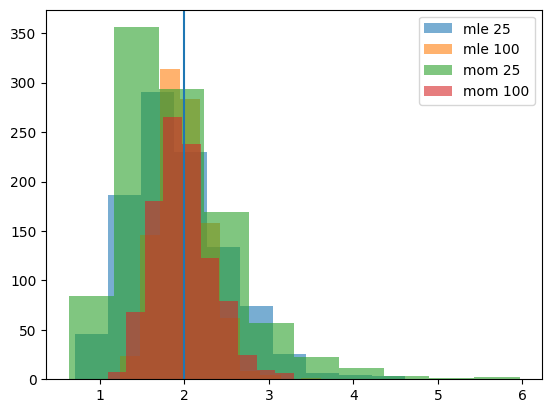

In [7]:

alpha = 0.6
plt.hist(get_beta(datasets[1], mle), alpha= alpha, label=f"mle 25")
plt.hist(get_beta(datasets[2], mle), alpha = alpha , label="mle 100")
plt.hist(get_beta(datasets[1], method_of_moments), alpha = alpha, label="mom 25")
plt.hist(get_beta(datasets[2], method_of_moments), alpha = alpha, label="mom 100")
plt.axvline(2)
plt.legend()
plt.show()


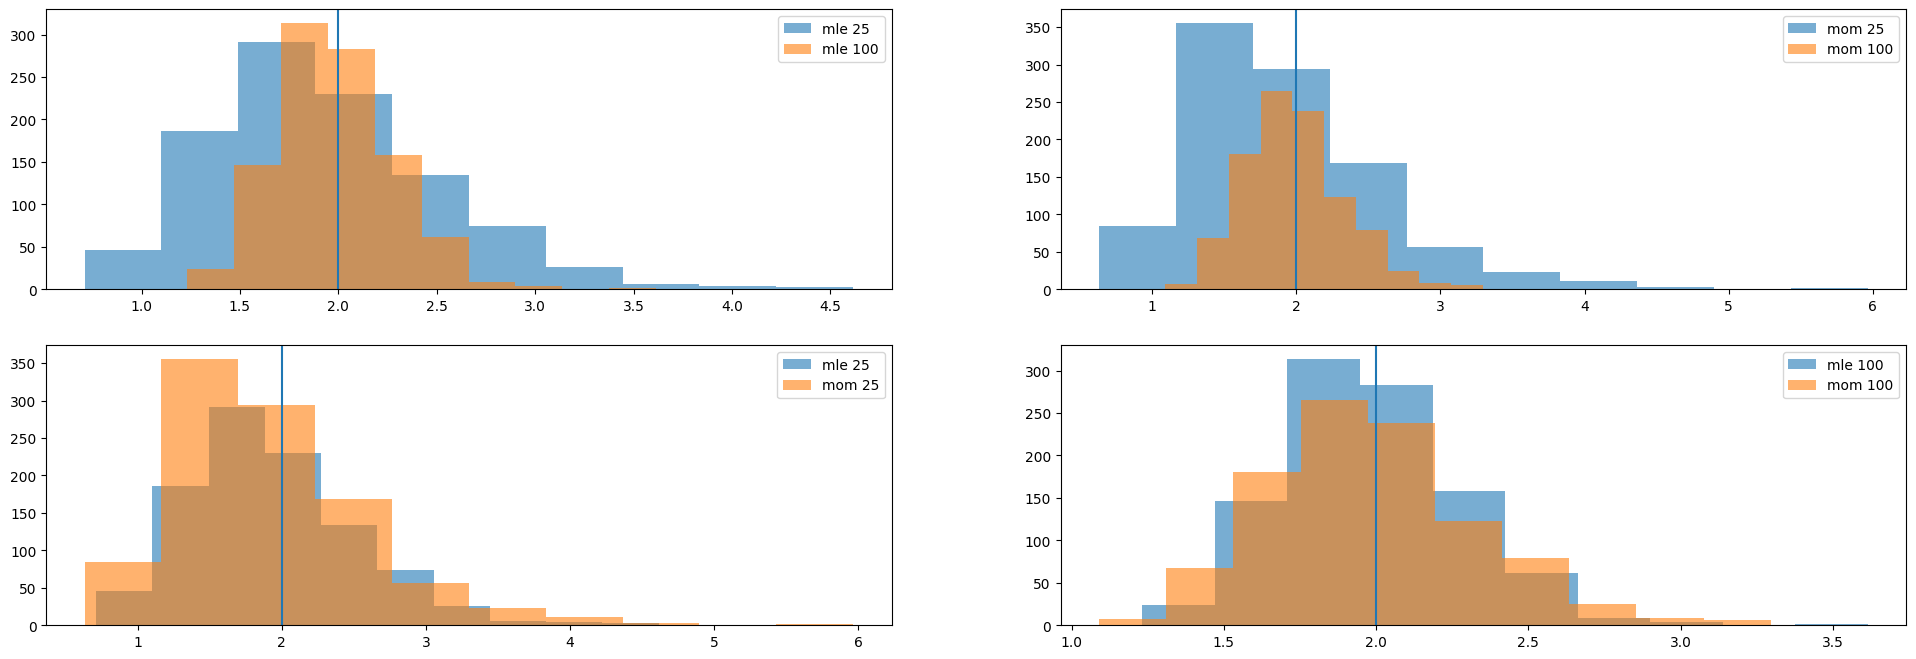

In [8]:

# (mle, *), (mom, *)
# (*, 25), (*, 100)
plt.figure(figsize = (24, 8))
plt.subplot(2, 2, 1)
plt.hist(get_beta(datasets[1], mle), alpha= alpha, label=f"mle 25")
plt.hist(get_beta(datasets[2], mle), alpha= alpha, label=f"mle 100")
plt.axvline(2)
plt.legend()
plt.subplot(2, 2, 2)
plt.hist(get_beta(datasets[1], method_of_moments), alpha= alpha, label=f"mom 25")
plt.hist(get_beta(datasets[2], method_of_moments), alpha= alpha, label=f"mom 100")
plt.axvline(2)
plt.legend()
plt.subplot(2, 2, 3)
plt.hist(get_beta(datasets[1], mle), alpha= alpha, label=f"mle 25")
plt.hist(get_beta(datasets[1], method_of_moments), alpha= alpha, label=f"mom 25")
plt.axvline(2)
plt.legend()
plt.subplot(2, 2, 4)
plt.hist(get_beta(datasets[2], mle), alpha= alpha, label=f"mle 100")
plt.hist(get_beta(datasets[2], method_of_moments), alpha= alpha, label=f"mom 100")
plt.axvline(2)
plt.legend()


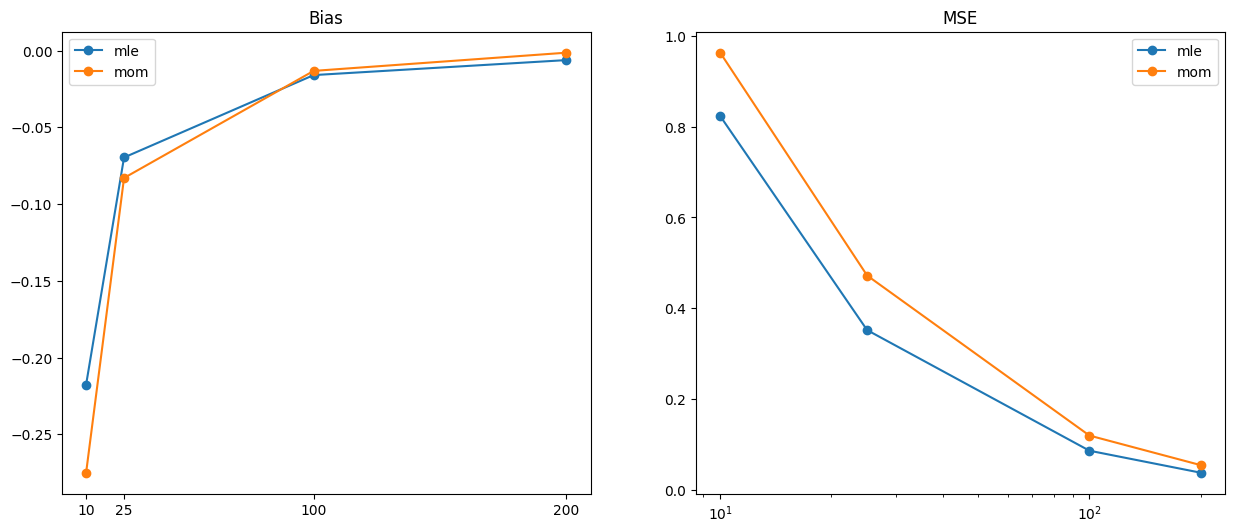

In [13]:

mle_biases = []
mom_biases = []
mle_mses = []
mom_mses = []
for d in datasets:
    mle_bias, _, mle_mse = calc_metrics(d, mle)
    mom_bias, _, mom_mse = calc_metrics(d, method_of_moments)
    mle_biases.append(mle_bias)
    mle_mses.append(mle_mse)
    mom_biases.append(mom_bias)
    mom_mses.append(mom_mse)

n = (10, 25, 100, 200)

plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
plt.title("Bias")
plt.plot(n, mle_biases, label = "mle", marker='o')
plt.plot(n, mom_biases, label = "mom", marker = 'o')
plt.xticks((10, 25, 100, 200))
plt.legend()

plt.subplot(1, 2, 2)
plt.title("MSE")
plt.plot(n, mle_mses, label = "mle", marker='o')
plt.plot(n, mom_mses, label = "mom", marker = 'o')
plt.xscale('log')
plt.legend()

/var/folders/0m/wjwgxmxs2xl1pdp5hqg8qgr00000gn/T/ipykernel_38217/3326726546.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


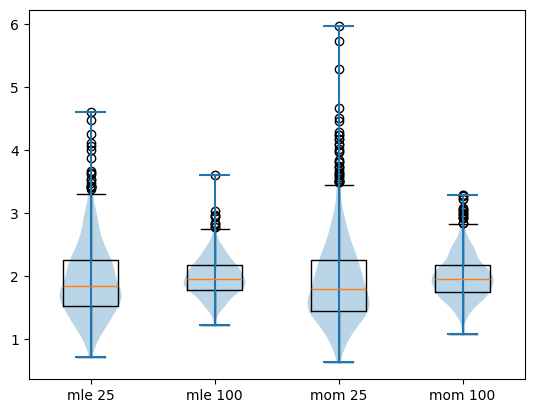

In [10]:
plt.boxplot(
    x = [
        get_beta(datasets[1], mle),  
        get_beta(datasets[2], mle),
        get_beta(datasets[1], method_of_moments),
        get_beta(datasets[2], method_of_moments),
    ],
    labels=[
        "mle 25",
        "mle 100",
        "mom 25",
        "mom 100",
    ])
plt.violinplot(
    [
        get_beta(datasets[1], mle),  
        get_beta(datasets[2], mle),
        get_beta(datasets[1], method_of_moments),
        get_beta(datasets[2], method_of_moments),
    ])
plt.show()